In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("scraped_electronics_dataset.csv")
print(df.shape)

(114, 6)


In [5]:
print(df.columns)
print(df.dtypes)

Index(['category', 'name', 'price', 'description', 'reviews', 'url'], dtype='str')
category           str
name               str
price              str
description        str
reviews        float64
url                str
dtype: object


In [6]:
display(df.head())
display(df.tail())

,category,name,price,description,reviews,url
0,Laptops,Asus VivoBook X441NA-GA190,$295.99,"Asus VivoBook X441NA-GA190 Chocolate Black, 14...",NaN,https://webscraper.io/test-sites/e-commerce/al...
1,Laptops,Prestigio SmartBook 133S Dark Grey,$299,"Prestigio SmartBook 133S Dark Grey, 13.3"" FHD ...",NaN,https://webscraper.io/test-sites/e-commerce/al...
2,Laptops,Prestigio SmartBook 133S Gold,$299,"Prestigio SmartBook 133S Gold, 13.3"" FHD IPS, ...",NaN,https://webscraper.io/test-sites/e-commerce/al...
3,Laptops,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",NaN,https://webscraper.io/test-sites/e-commerce/al...
4,Laptops,Lenovo V110-15IAP,$321.94,"Lenovo V110-15IAP, 15.6"" HD, Celeron N3350 1.1...",NaN,https://webscraper.io/test-sites/e-commerce/al...


,category,name,price,description,reviews,url
109,Phones (Touch),Samsung Galaxy,$93.99,5 mpx. Android 5.0,NaN,https://webscraper.io/test-sites/e-commerce/al...
110,Phones (Touch),Nokia X,$109.99,"Andoid, Jolla dualboot",NaN,https://webscraper.io/test-sites/e-commerce/al...
111,Phones (Touch),Sony Xperia,$118.99,"GPS, waterproof",NaN,https://webscraper.io/test-sites/e-commerce/al...
112,Phones (Touch),Ubuntu Edge,$499.99,Sapphire glass,NaN,https://webscraper.io/test-sites/e-commerce/al...
113,Phones (Touch),Iphone,$899.99,White,NaN,https://webscraper.io/test-sites/e-commerce/al...


In [7]:
print(df.isnull().sum())

category         0
name             0
price            0
description      0
reviews        114
url              0
dtype: int64


In [8]:
print(df.isnull().mean() * 100)

category         0.0
name             0.0
price            0.0
description      0.0
reviews        100.0
url              0.0
dtype: float64


In [9]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [12]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)
print(df['price'].describe())

count     114.000000
mean      746.869035
std       467.461378
min        24.990000
25%       383.432500
50%       606.990000
75%      1166.085000
max      1799.000000
Name: price, dtype: float64


In [13]:
print(df['category'].value_counts())

category
Laptops           88
Tablets           19
Phones (Touch)     7
Name: count, dtype: int64


In [14]:
avg_price_by_category = df.groupby('category')['price'].mean().sort_values(ascending=False)
print(avg_price_by_category)

category
Laptops           898.435568
Phones (Touch)    257.990000
Tablets           224.990000
Name: price, dtype: float64


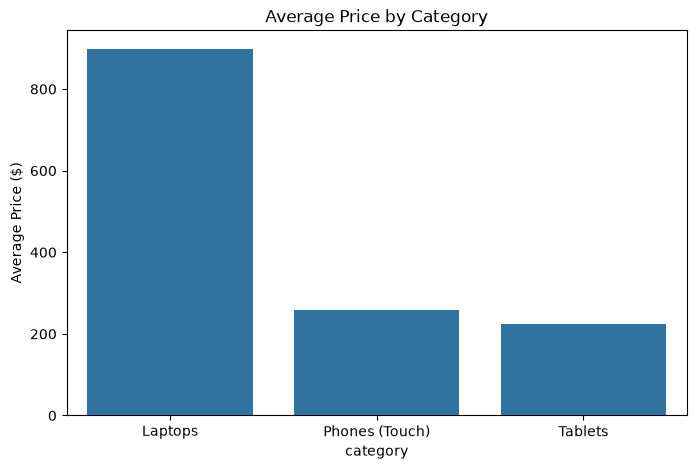

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(x=avg_price_by_category.index, y=avg_price_by_category.values)
plt.title("Average Price by Category")
plt.ylabel("Average Price ($)")
plt.show()

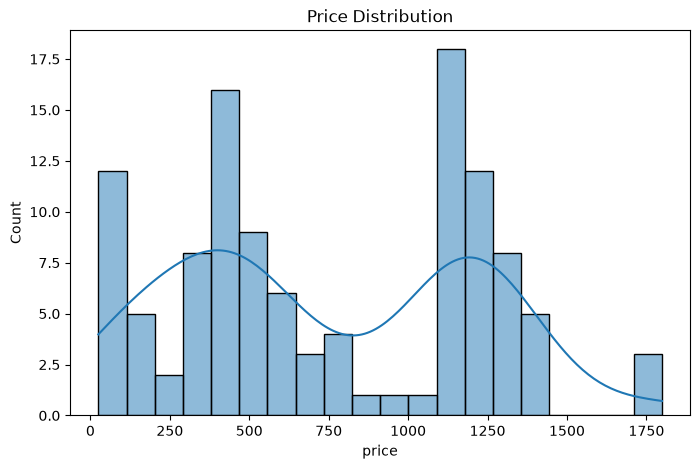

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

In [17]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
display(outliers)

Number of outliers: 0


,category,name,price,description,reviews,url


In [18]:
laptops_avg = df[df['category'] == 'Laptops']['price'].mean()
tablets_avg = df[df['category'] == 'Tablets']['price'].mean()
print(f"Average Laptop price: ${laptops_avg:.2f}")
print(f"Average Tablet price: ${tablets_avg:.2f}")
print(f"Difference: ${abs(laptops_avg - tablets_avg):.2f}")

Average Laptop price: $898.44
Average Tablet price: $224.99
Difference: $673.45


In [19]:
print("Data Summary")
print(f"Total products: {len(df)}")
print(f"Categories: {df['category'].unique()}")
print(f"Average price: ${df['price'].mean():.2f}")
print(f"Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
print(f"Most expensive category: {avg_price_by_category.idxmax()}")
print(f"Least expensive category: {avg_price_by_category.idxmin()}")

Data Summary
Total products: 114
Categories: <StringArray>
['Laptops', 'Tablets', 'Phones (Touch)']
Length: 3, dtype: str
Average price: $746.87
Price range: $24.99 - $1799.00
Most expensive category: Laptops
Least expensive category: Tablets
